SVD 分解
A = 
 [[3 1]
 [1 2]]

U = 
[[-0.851 -0.526]
 [-0.526  0.851]]
奇异值 Σ: [3.618 1.382]
V^T = 
[[-0.851 -0.526]
 [-0.526  0.851]]

A_reconstructed = U Σ V^T:
[[3. 1.]
 [1. 2.]]
与原 A 相等？ True


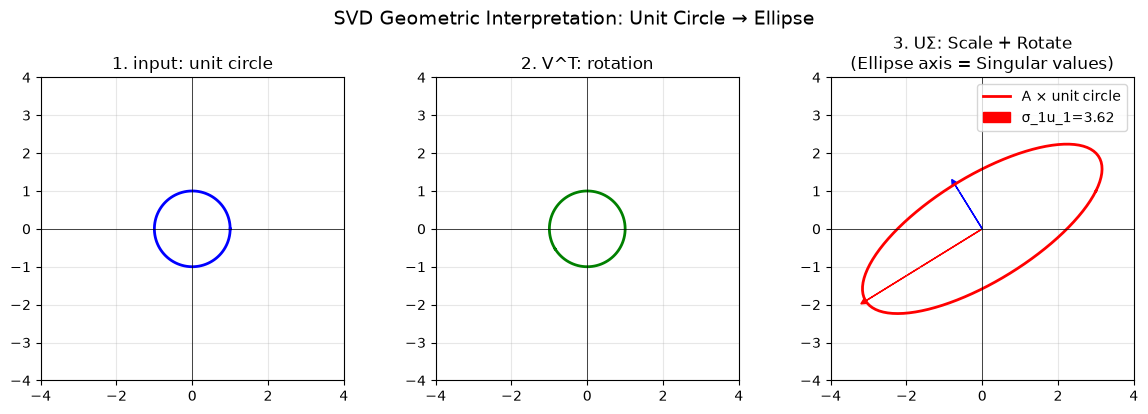


SVD 的秩1分解
A = σ₁ u₁ v₁^T + σ₂ u₂ v₂^T + ...

第 1 项 (σ_1 = 3.618):
[[2.618 1.618]
 [1.618 1.   ]]

第 2 项 (σ_2 = 1.382):
[[ 0.382 -0.618]
 [-0.618  1.   ]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd

# ---- 创建一个 2x2 矩阵 ----
A = np.array([[3, 1], [1, 2]])
print("=" * 60)
print("SVD 分解")
print("=" * 60)
print("A = \n", A)

# ---- SVD 分解 ----
U, S, Vt = svd(A)
print(f"\nU = \n{U.round(3)}")
print(f"奇异值 Σ: {S.round(3)}")
print(f"V^T = \n{Vt.round(3)}")

# ---- 验证: A = U @ diag(S) @ Vt ----
Sigma = np.diag(S)
A_reconstructed = U @ Sigma @ Vt
print(f"\nA_reconstructed = U Σ V^T:\n{A_reconstructed.round(3)}")
print(f"与原 A 相等？ {np.allclose(A, A_reconstructed)}")

# ---- 几何可视化：单位圆 → 椭圆 ----
theta = np.linspace(0, 2*np.pi, 100)
circle = np.array([np.cos(theta), np.sin(theta)])

# 应用 V^T（旋转）
circle_rotated = Vt @ circle

# 应用 Σ（缩放）
circle_scaled = np.array([[S[0] * circle_rotated[0, :]],
                          [S[1] * circle_rotated[1, :]]]).squeeze()

# 应用 U（旋转）
ellipse = U @ circle_scaled

plt.figure(figsize=(12, 4))

# 图1：原始单位圆
plt.subplot(1, 3, 1)
plt.plot(circle[0, :], circle[1, :], 'b-', linewidth=2)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.title('1. input: unit circle')
plt.gca().set_aspect('equal')
plt.grid(alpha=0.3)

# 图2：V^T（旋转）
plt.subplot(1, 3, 2)
plt.plot(circle_rotated[0, :], circle_rotated[1, :], 'g-', linewidth=2)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.title('2. V^T: rotation')
plt.gca().set_aspect('equal')
plt.grid(alpha=0.3)

# 图3：UΣ（缩放 + 旋转）
plt.subplot(1, 3, 3)
plt.plot(ellipse[0, :], ellipse[1, :], 'r-', linewidth=2, label='A × unit circle')
# 画奇异向量方向
for i in range(2):
    vec_u = U[:, i] * S[i]
    plt.arrow(0, 0, vec_u[0], vec_u[1], 
             head_width=0.15, head_length=0.15,
             fc='red' if i==0 else 'blue',
             ec='red' if i==0 else 'blue',
             label=f'σ_{i+1}u_{i+1}={S[i]:.2f}' if i==0 else '')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
# plt.title('3. UΣ: 缩放 + 旋转\n(椭圆轴 = 奇异值)')
plt.title('3. UΣ: Scale + Rotate\n(Ellipse axis = Singular values)')
plt.legend()
plt.gca().set_aspect('equal')
plt.grid(alpha=0.3)

# plt.suptitle('SVD 的几何意义: 单位圆 → 椭圆', fontsize=14)
plt.suptitle('SVD Geometric Interpretation: Unit Circle → Ellipse', fontsize=14)
plt.tight_layout()
plt.show()

# ---- 秩为1的分解 ----
print("\n" + "=" * 60)
print("SVD 的秩 1 分解")
print("=" * 60)
print("A = σ₁ u₁ v₁^T + σ₂ u₂ v₂^T + ...")
for i in range(len(S)):
    rank1 = S[i] * np.outer(U[:, i], Vt[i, :])
    print(f"\n第 {i+1} 项 (σ_{i+1} = {S[i]:.3f}):")
    print(rank1.round(3))